# 01 — EDA: кредитный скоринг (UCI Default of Credit Card Clients)

Разведочный анализ открытого датасета **"Default of Credit Card Clients"**
(Yeh, I-C. & Lien, C.-H., 2009), UCI Machine Learning Repository:
https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients

30000 анонимизированных клиентов тайваньского банка, по каждому — кредитный
лимит, демографика, история выставленных счетов и платежей за 6 месяцев,
целевая переменная — допустил ли клиент дефолт в следующем месяце.

Сырой файл лежит в `../data/raw/uci_credit_card_default_raw.csv`. Очистка
аномалий и построение признаков — в `src/data/prepare_data.py`, здесь —
разбор того, что и почему было сделано.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

raw = pd.read_csv("../data/raw/uci_credit_card_default_raw.csv")
raw.shape

(30000, 25)

## Сырые данные: структура и аномалии

In [2]:
raw.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [3]:
raw.isna().sum().sum()

np.int64(0)

Пропусков как таковых нет, но это не значит, что данные чистые — в категориальных признаках встречаются недокументированные коды.

In [4]:
raw["EDUCATION"].value_counts().sort_index()

EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

In [5]:
raw["MARRIAGE"].value_counts().sort_index()

MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

По документации датасета `EDUCATION` должен принимать значения 1-4
(graduate school / university / high school / others), но встречаются
0, 5, 6 — недокументированные коды (всего ~468 строк). Аналогично
`MARRIAGE` должен быть 1-3, но встречается 0 (54 строки). Это типичная
для реальных данных ситуация, в синтетике такого не бывает — в `prepare_data.py`
эти коды свёрнуты в категорию "others", а не выброшены, чтобы не терять строки.

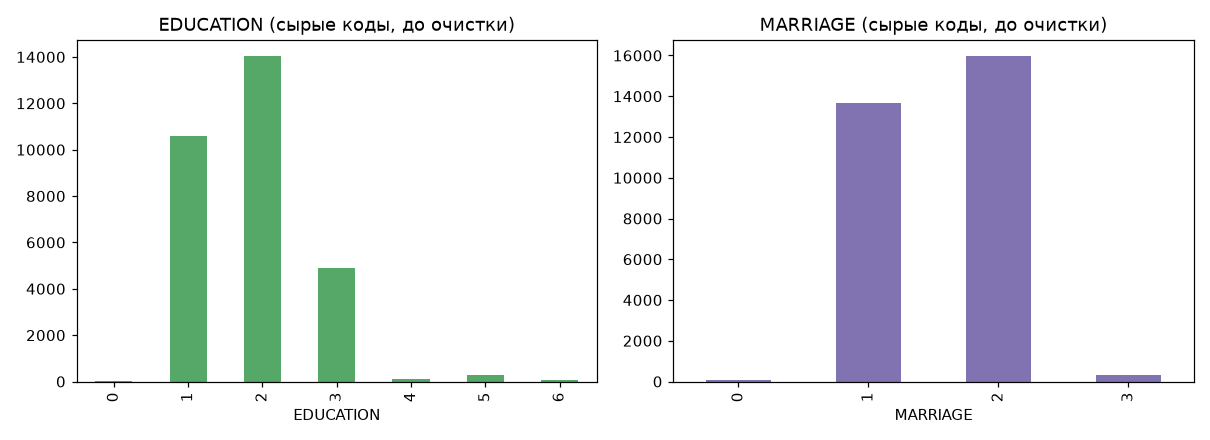

In [6]:
from IPython.display import Image
Image("figures/raw_category_anomalies.png")

## Обработанный датасет

In [7]:
df = pd.read_csv("../data/credit_data_full.csv")
df.shape

(30000, 13)

In [8]:
df.describe().round(3)

,LIMIT_BAL,EDUCATION,MARRIAGE,AGE,max_delay,mean_delay,n_months_delayed,avg_bill_amt,avg_pay_amt,payment_to_bill_ratio,credit_utilization,bill_trend,default
count,30000.000,30000.000,30000.000,30000.000,30000.000,30000.000,30000.000,30000.000,30000.000,30000.000,30000.000,30000.000,30000.000
mean,167484.323,1.842,1.557,35.486,0.439,-0.182,0.834,44976.945,5275.232,0.393,0.373,-2631.745,0.221
std,129747.662,0.744,0.521,9.218,1.345,0.982,1.554,63260.722,10137.946,0.659,0.352,9159.552,0.415
min,10000.000,1.000,1.000,21.000,-2.000,-2.000,0.000,-56043.167,0.000,0.000,-0.233,-135143.629,0.000
25%,50000.000,1.000,1.000,28.000,0.000,-0.833,0.000,4781.333,1113.292,0.041,0.030,-4145.657,0.000
50%,140000.000,2.000,2.000,34.000,0.000,0.000,0.000,21051.833,2397.167,0.088,0.285,-218.600,0.000
75%,240000.000,2.000,2.000,41.000,2.000,0.000,1.000,57104.417,5583.917,0.609,0.688,606.579,0.000
max,1000000.000,4.000,3.000,79.000,8.000,6.000,6.000,877313.833,627344.333,5.000,5.000,99374.714,1.000


## Распределение целевой переменной

In [9]:
df['default'].value_counts(normalize=True)

default
0    0.7788
1    0.2212
Name: proportion, dtype: float64

22.1% клиентов вышли в дефолт — дисбаланс заметный, но не экстремальный (в отличие от типичного fraud-detection с долями процента).

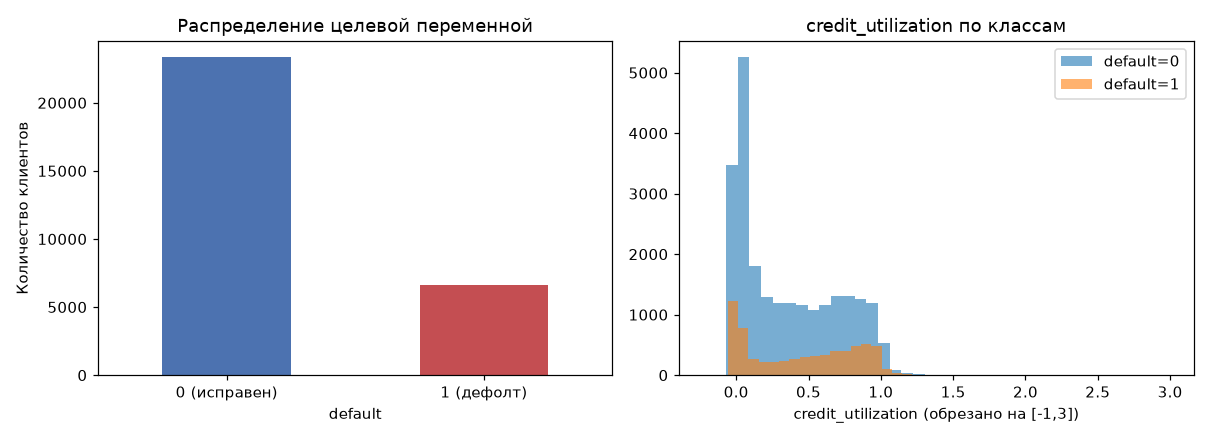

In [10]:
from IPython.display import Image
Image("figures/target_distribution.png")

**Рисунок 1.1** — слева баланс классов, справа `credit_utilization` (средний счёт / кредитный лимит) по классам: у дефолтных клиентов распределение явно сдвинуто в сторону больших значений — высокая загрузка лимита логично связана с риском невозврата.

## Корреляция инженерных признаков с целевой переменной

In [11]:
df.corr(numeric_only=True)['default'].sort_values()

LIMIT_BAL               -0.153520
avg_pay_amt             -0.102354
payment_to_bill_ratio   -0.080518
MARRIAGE                -0.027575
avg_bill_amt            -0.012691
AGE                      0.013890
bill_trend               0.024184
EDUCATION                0.033842
credit_utilization       0.115556
mean_delay               0.281955
max_delay                0.331036
n_months_delayed         0.398394
default                  1.000000
Name: default, dtype: float64

Самая сильная связь — у признаков просрочки: `n_months_delayed` (0.40),
`max_delay` (0.33), `mean_delay` (0.28) — все они построены из истории
`PAY_0...PAY_6` за 6 месяцев и логично доминируют. `credit_utilization`
(0.12) тоже заметно коррелирует. `LIMIT_BAL` отрицательно связан (-0.15) —
банк сам выдаёт более высокие лимиты надёжным клиентам, поэтому здесь
есть смешение причины и следствия (лимит — не только риск-фактор,
но и результат предыдущей оценки риска тем же банком).
`AGE`, `EDUCATION`, `MARRIAGE`, `bill_trend` почти не коррелируют линейно
с целью — демографические признаки в этом датасете слабее, чем поведенческие.

## Выводы по EDA

- Сырые данные требуют очистки категориальных кодов (`EDUCATION`, `MARRIAGE`) —
  в реальных данных это типично, в отличие от синтетики.
- Дисбаланс классов 78/22 — учтён через `class_weight="balanced"` для
  линейной модели и через метрики, устойчивые к дисбалансу (ROC-AUC), при
  подборе порога по F1 для моделей с тюнингом.
- Признаки истории просрочек (`PAY_0...PAY_6`) — главный источник сигнала;
  агрегаты по ним (`max_delay`, `mean_delay`, `n_months_delayed`) дают
  наибольшую корреляцию с целью среди всех построенных признаков.
- Признак `payment_to_bill_ratio` потребовал отдельной обрезки выбросов
  (деление на околонулевые суммы счетов давало значения до 10^5) — без
  этого шага модель переоценивала бы важность пары аномальных строк.